In [4]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

In [6]:
data_path = Path("../data/raw")
print(data_path)

..\data\raw


In [7]:
print(data_path.exists())

True


In [8]:
for item in data_path.iterdir():
    print(item)

..\data\raw\CIFAKE


In [9]:
data_path = Path("../data/raw/CIFAKE")

In [10]:
print(data_path.exists())

True


In [11]:
for item in data_path.iterdir():
    print(item)

..\data\raw\CIFAKE\test
..\data\raw\CIFAKE\train


In [12]:
train_path = data_path / "train"

for item in train_path.iterdir():
    print(item)

..\data\raw\CIFAKE\train\FAKE
..\data\raw\CIFAKE\train\REAL


In [13]:
REAL = 0
FAKE = 1

In [14]:
def count_images(folder):
    extensions = {".jpg", ".jpeg", ".png", ".webp"}
    
    return sum(
        1
        for file in folder.rglob("*")
        if file.suffix.lower() in extensions
    )

In [15]:
real_path = train_path / "REAL"
fake_path = train_path / "FAKE"

print("Real images:", count_images(real_path))
print("Fake images:", count_images(fake_path))

Real images: 50000
Fake images: 50000


In [16]:
real_images = list(real_path.glob("*"))

print(real_images[0])

..\data\raw\CIFAKE\train\REAL\0000 (10).jpg


In [18]:
image = Image.open(real_images[0])

print(image)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=32x32 at 0x2467A489940>


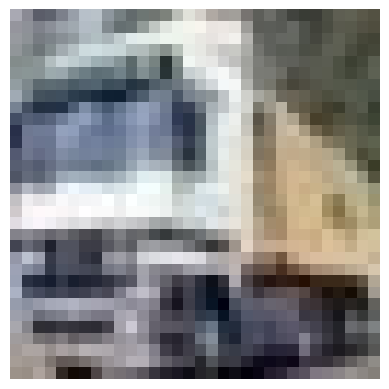

In [19]:
plt.imshow(image)
plt.axis("off")
plt.show()

In [20]:
print("Size:", image.size)
print("Mode:", image.mode)

Size: (32, 32)
Mode: RGB


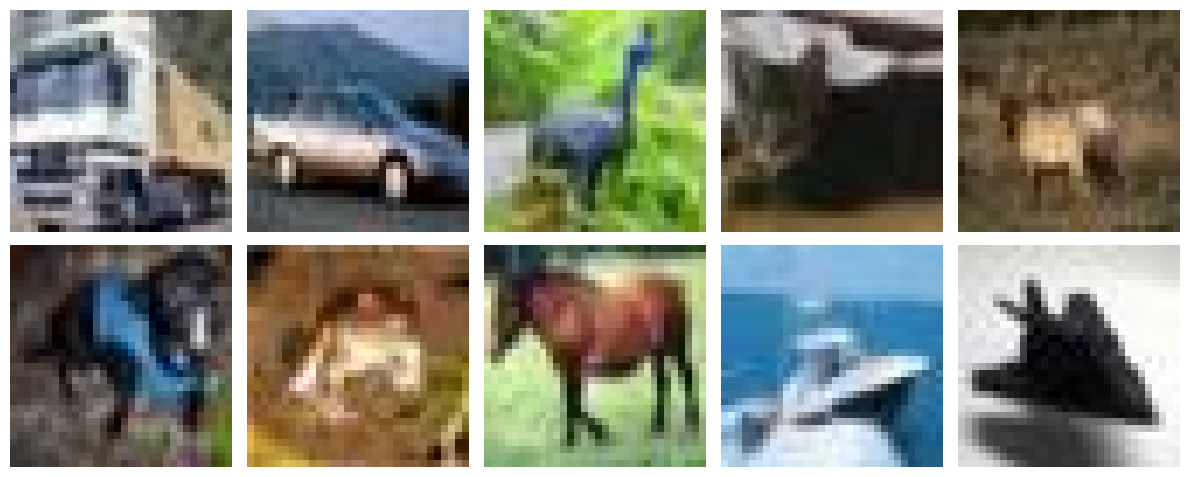

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, image_path in zip(axes.flatten(), real_images[:10]):
    image = Image.open(image_path)
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

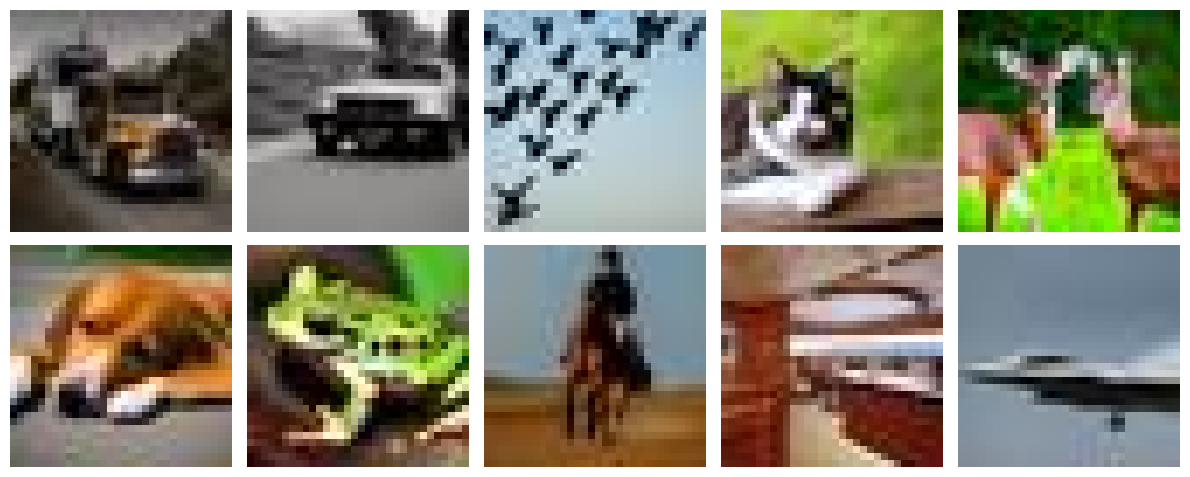

In [22]:
fake_images = list(fake_path.glob("*"))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, image_path in zip(axes.flatten(), fake_images[:10]):
    image = Image.open(image_path)
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
extensions = {}

for file in train_path.rglob("*"):
    if file.is_file():
        ext = file.suffix.lower()
        extensions[ext] = extensions.get(ext, 0) + 1

extensions

{'.jpg': 100000}

In [24]:
def check_images(folder):
    bad_images = []

    for image_path in folder.rglob("*"):
        if image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}:
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except Exception:
                bad_images.append(image_path)

    return bad_images

In [25]:
bad_real = check_images(real_path)
bad_fake = check_images(fake_path)

print("Bad REAL images:", len(bad_real))
print("Bad FAKE images:", len(bad_fake))

Bad REAL images: 0
Bad FAKE images: 0
